# CIFAR10 LaBo — Selected Concepts Inspector

Inspect the concepts selected by the submodular algorithm for the CIFAR10 1-shot experiment.

In [4]:
import os, json
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_ROOT         = 'exp/asso_opt/CIFAR10/CIFAR10_2shot_fac'
CONCEPT_ROOT      = 'datasets/CIFAR10/concepts'
CLS_NAMES_PATH    = f'{CONCEPT_ROOT}/cls_names.npy'
CONCEPTS_RAW_PATH = f'{CONCEPT_ROOT}/concepts_raw.npy'
CONCEPT2CLS_PATH  = f'{CONCEPT_ROOT}/concept2cls.npy'
CLASS2CONCEPTS_JSON = f'{CONCEPT_ROOT}/class2concepts.json'
SELECT_IDX_PATH   = f'{DATA_ROOT}/select_idx.pth'
NUM_CONCEPT       = 500   # 50 per class × 10 classes

print("Paths configured.")

Paths configured.


## 1 — Load concept files

In [6]:
# Load the deduplicated concept pool saved by DotProductDataModule
# (select_idx indexes into THIS array, not the original datasets/ one)
cls_names    = np.load(CLS_NAMES_PATH).tolist()
concepts_raw = np.load(f'{DATA_ROOT}/concepts_raw_selected.npy')
concept2cls  = np.load(f'{DATA_ROOT}/concept2cls_selected.npy').astype(int)

# Load the indices chosen by submodular_select
select_idx        = torch.load(SELECT_IDX_PATH)[:NUM_CONCEPT]
selected_concepts = concepts_raw[select_idx]
selected_cls      = concept2cls[select_idx]

print(f"Deduplicated concept pool : {len(concepts_raw)}")
print(f"Selected concepts         : {len(selected_concepts)}")
print(f"Classes ({len(cls_names)}): {cls_names}")

IndexError: index 1090 is out of bounds for axis 0 with size 126

In [22]:
from collections import Counter

counts = Counter(selected_cls.tolist())

print("\nConcepts per class:")
for i, name in enumerate(cls_names):
    print(f"{name:12s} : {counts[i]}")
    
print("\nTotal:", sum(counts.values()))


Concepts per class:
airplane     : 50
automobile   : 50
bird         : 50
cat          : 50
deer         : 50
dog          : 50
frog         : 50
horse        : 50
ship         : 50
truck        : 50

Total: 500


In [23]:
# Build a DataFrame: one row per selected concept
df = pd.DataFrame({
    'class_idx': selected_cls,
    'class_name': [cls_names[i] for i in selected_cls],
    'concept':    selected_concepts,
})
print(f"Shape: {df.shape}")
df.head(20)

Shape: (500, 3)


,class_idx,class_name,concept
0,0,airplane,airline livery visible
1,0,airplane,fuselage windows in a row
2,0,airplane,jet exhaust trails
3,0,airplane,sharply angled fuselage
4,0,airplane,metal bird
5,0,airplane,ridged body aircraft
6,0,airplane,underslung engines
7,0,airplane,ocean deep
8,0,airplane,fuselage curves smoothly
9,0,airplane,polished steel fuselage


## 2 — Concepts per class (browsable table)

In [24]:
# Print concepts grouped by class — change class_filter to focus on one class
class_filter = None  # e.g. 'airplane' or None for all

for cls in cls_names:
    if class_filter and cls != class_filter:
        continue
    subset = df[df['class_name'] == cls]['concept'].tolist()
    print(f"\n{'─'*60}")
    print(f"  {cls.upper()}  ({len(subset)} concepts)")
    print(f"{'─'*60}")
    for c in subset:
        print(f"  • {c}")


────────────────────────────────────────────────────────────
  AIRPLANE  (50 concepts)
────────────────────────────────────────────────────────────
  • airline livery visible
  • fuselage windows in a row
  • jet exhaust trails
  • sharply angled fuselage
  • metal bird
  • ridged body aircraft
  • underslung engines
  • ocean deep
  • fuselage curves smoothly
  • polished steel fuselage
  • bright red accents
  • window lined fuselage
  • powerful jet engines
  • curved fuselage
  • gleaming fuselage
  • window rows along fuselage
  • cloud white fuselage
  • large swept wings
  • window strip along fuselage
  • long slender fuselage
  • fuselage windows in line
  • long narrow fuselage
  • landing gear wheels
  • streamlined fuselage
  • long tube with wings
  • engines beneath wings
  • jet exhaust trail
  • engine nacelles beneath wings
  • metal bird soaring
  • horizontal stabilizers
  • long tube wings
  • wingtip to wingtip span
  • shiny fuselage
  • flat bottom fuselage
  • 

## 3 — Concepts per class bar chart

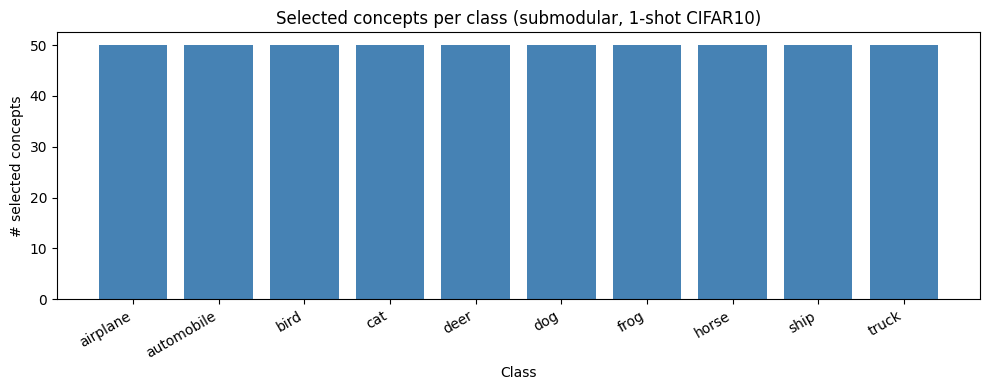

In [25]:
counts = df['class_name'].value_counts().reindex(cls_names)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(counts.index, counts.values, color='steelblue')
ax.set_xlabel('Class')
ax.set_ylabel('# selected concepts')
ax.set_title('Selected concepts per class (submodular, 1-shot CIFAR10)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4 — Association matrix weights (from trained checkpoint)

How strongly does each selected concept associate with each class after training?

In [29]:
import sys
sys.path.insert(0, '.')
from models.asso_opt.asso_opt import AssoConceptFast
import torch.nn.functional as F

CKPT = 'exp/asso_opt/CIFAR10/CIFAR10_1shot_fac/epoch=579-step=2900-val_acc=0.8186.ckpt'

model = AssoConceptFast.load_from_checkpoint(CKPT, map_location='cpu', weights_only=False)
model.eval()

# asso_mat shape: (num_cls, num_concept) = (10, 500)
asso_mat = F.softmax(model.asso_mat.detach(), dim=-1).numpy()
print(f"asso_mat shape: {asso_mat.shape}")   # (10, 500)

asso_mat shape: (10, 500)


In [30]:
# Top-k concepts per class by learned association weight
TOP_K = 10

print(f"Top {TOP_K} concepts per class (by association weight after training)\n")
for cls_idx, cls_name in enumerate(cls_names):
    weights = asso_mat[cls_idx]          # (500,)
    top_k_idx = np.argsort(weights)[::-1][:TOP_K]
    print(f"\n{'─'*60}")
    print(f"  {cls_name.upper()}")
    print(f"{'─'*60}")
    for rank, concept_idx in enumerate(top_k_idx):
        print(f"  {rank+1:>2}. [{weights[concept_idx]:.4f}]  {selected_concepts[concept_idx]}")

Top 10 concepts per class (by association weight after training)


────────────────────────────────────────────────────────────
  AIRPLANE
────────────────────────────────────────────────────────────
   1. [0.0048]  bright red accents
   2. [0.0048]  tinted cockpit windows
   3. [0.0048]  fuselage windows in a row
   4. [0.0048]  window rows along fuselage
   5. [0.0048]  window strip along fuselage
   6. [0.0048]  engines underneath wings
   7. [0.0048]  metal bird
   8. [0.0048]  metal bird soaring
   9. [0.0048]  jet exhaust trails
  10. [0.0045]  ocean deep

────────────────────────────────────────────────────────────
  AUTOMOBILE
────────────────────────────────────────────────────────────
   1. [0.0048]  four wheeled vehicle
   2. [0.0048]  visible wheel rims
   3. [0.0048]  alloy wheels
   4. [0.0048]  large alloy wheels
   5. [0.0048]  four wheels on the ground
   6. [0.0048]  distinct front grille
   7. [0.0048]  distinctive front grille
   8. [0.0048]  four equal wheels
   9.

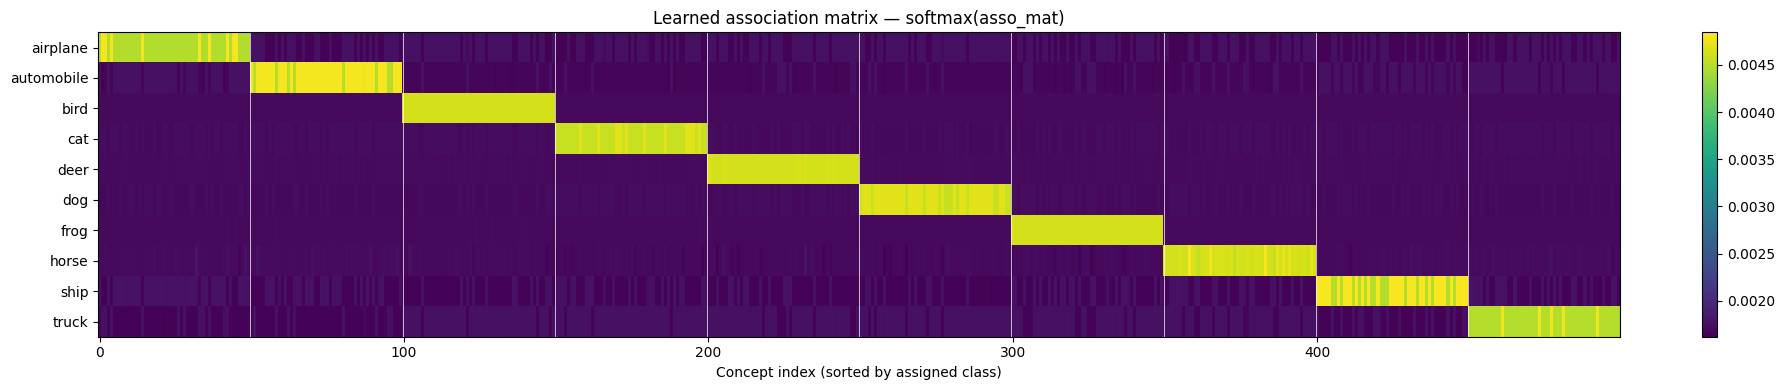

In [31]:
# Heatmap: association matrix (classes × concepts), concepts sorted by assigned class
sort_order = np.argsort(selected_cls)
sorted_mat  = asso_mat[:, sort_order]
sorted_cls  = selected_cls[sort_order]

# vertical lines separating classes
boundaries = np.where(np.diff(sorted_cls))[0] + 1

fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(sorted_mat, aspect='auto', cmap='viridis')
for b in boundaries:
    ax.axvline(b - 0.5, color='white', linewidth=0.5)
ax.set_yticks(range(len(cls_names)))
ax.set_yticklabels(cls_names)
ax.set_xlabel('Concept index (sorted by assigned class)')
ax.set_title('Learned association matrix — softmax(asso_mat)')
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.show()

## 5 — Concept–Image similarity distributions

In [32]:
import glob, torch.nn.functional as F

# Load concept CLIP features and train image features
concept_feat = torch.load(f'{DATA_ROOT}/concepts_feat_ViT-L-14.pth')       # (pool, 768)
concept_feat_sel = concept_feat[select_idx]                                  # (500, 768)

img_feat_path = glob.glob('datasets/CIFAR10/splits/img_feat_train_1_*.pth')[0]
img_feat = torch.load(img_feat_path)                                         # (10, 768)

# Normalize for cosine similarity
concept_norm = F.normalize(concept_feat_sel.float(), dim=-1)
img_norm     = F.normalize(img_feat.float(), dim=-1)

# sim: (10 images, 500 concepts)
sim = (img_norm @ concept_norm.t()).numpy()
print(f"Similarity matrix shape: {sim.shape}  (images × concepts)")

Similarity matrix shape: (10, 500)  (images × concepts)


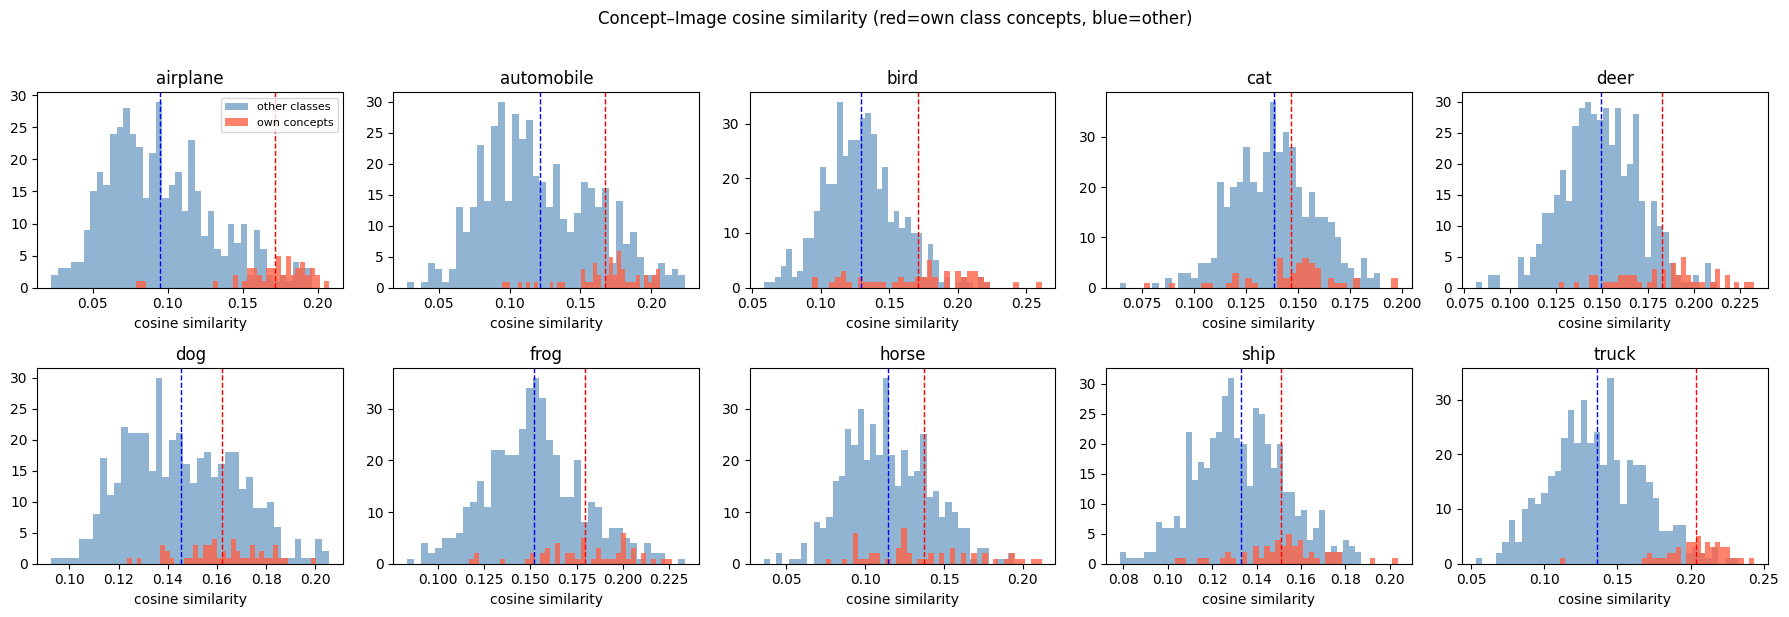

In [35]:
# Distribution of concept similarities per class
# For each class: take its 1 training image, plot similarity to all 500 concepts
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=False)
axes = axes.flatten()

for cls_idx, cls_name in enumerate(cls_names):
    sims = sim[cls_idx]                            # similarities from this class image to all 500 concepts
    own  = sims[selected_cls == cls_idx]           # concepts assigned to this class
    other = sims[selected_cls != cls_idx]          # concepts assigned to other classes

    axes[cls_idx].hist(other, bins=40, color='steelblue', alpha=0.6, label='other classes')
    axes[cls_idx].hist(own,   bins=40, color='tomato',    alpha=0.8, label='own concepts')
    axes[cls_idx].set_title(cls_name)
    axes[cls_idx].set_xlabel('cosine similarity')
    axes[cls_idx].axvline(own.mean(),   color='red',  linestyle='--', linewidth=1)
    axes[cls_idx].axvline(other.mean(), color='blue', linestyle='--', linewidth=1)

axes[0].legend(fontsize=8)
plt.suptitle('Concept–Image cosine similarity (red=own class concepts, blue=other)', y=1.02)
plt.tight_layout()
plt.show()

In [36]:
# Summary: mean similarity of own-class vs other-class concepts per class
print(f"{'Class':<14} {'Own mean':>10} {'Other mean':>12} {'Gap':>8}")
print("─" * 48)
for cls_idx, cls_name in enumerate(cls_names):
    sims  = sim[cls_idx]
    own   = sims[selected_cls == cls_idx].mean()
    other = sims[selected_cls != cls_idx].mean()
    print(f"{cls_name:<14} {own:>10.4f} {other:>12.4f} {own-other:>8.4f}")

Class            Own mean   Other mean      Gap
────────────────────────────────────────────────
airplane           0.1714       0.0951   0.0763
automobile         0.1672       0.1211   0.0461
bird               0.1713       0.1296   0.0417
cat                0.1467       0.1384   0.0083
deer               0.1825       0.1494   0.0331
dog                0.1622       0.1456   0.0166
frog               0.1796       0.1521   0.0275
horse              0.1370       0.1143   0.0228
ship               0.1511       0.1330   0.0180
truck              0.2034       0.1360   0.0674


In [11]:
import utils
from models.select_concept.select_algo import submodular_select

# ── Load your custom concepts ────────────────────────────────────────────────
MY_CONCEPTS_JSON = 'datasets/CIFAR10/concepts/class2concepts_gemini.json'

# If your JSON uses different class names, map them to the official CIFAR10 names here.
# Set to None to use the JSON keys as-is (they must then already match cls_names).
NAME_MAP = None
# Example:
# NAME_MAP = {
#     'planes':      'airplane',
#     'cars':        'automobile',
#     'birds':       'bird',
#     'cats':        'cat',
#     'deer':        'deer',
#     'dogs':        'dog',
#     'frogs':       'frog',
#     'horses':      'horse',
#     'ships':       'ship',
#     'trucks':      'truck',
# }

class2concepts_raw = json.load(open(MY_CONCEPTS_JSON))

# Apply name mapping if provided
if NAME_MAP is not None:
    class2concepts = {NAME_MAP.get(k, k): v for k, v in class2concepts_raw.items()}
else:
    class2concepts = class2concepts_raw

# Validate all keys are known CIFAR10 classes
official_cls = set(cls_names)
unknown = set(class2concepts.keys()) - official_cls
if unknown:
    print(f"⚠️  Unknown class names (not in CIFAR10): {unknown}")
    print(f"   Set NAME_MAP to remap them.")
else:
    print("✓ All class names match CIFAR10 classes.")

my_cls_names  = sorted(class2concepts.keys())
my_concepts   = []
my_concept2cls = []
for cls_idx, cls_name in enumerate(my_cls_names):
    for concept in class2concepts[cls_name]:
        my_concepts.append(concept)
        my_concept2cls.append(cls_idx)

my_concept2cls = np.array(my_concept2cls)
print(f"Total concepts: {len(my_concepts)}  |  classes: {my_cls_names}")

✓ All class names match CIFAR10 classes.
Total concepts: 832  |  classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [12]:
# ── Compute CLIP text features for your concepts ─────────────────────────────
# This may take ~30s for ~6700 concepts
my_concept_feat = utils.prepare_txt_feat(my_concepts, clip_model_name='ViT-L/14')
print(f"Concept feat shape: {my_concept_feat.shape}")

100%|██████████| 7/7 [00:00<00:00, 12.76it/s]

Concept feat shape: torch.Size([832, 768])


In [13]:
# ── Load cached train image features (already computed during training) ───────
import glob
img_feat_path = glob.glob('datasets/CIFAR10/splits/img_feat_train_1_*.pth')[0]
img_feat = torch.load(img_feat_path)
print(f"Image feat shape: {img_feat.shape}  (n_shots×n_classes, dim) = (10, 768)")

Image feat shape: torch.Size([10, 768])  (n_shots×n_classes, dim) = (10, 768)


In [14]:
# ── Run submodular selection on your concepts ─────────────────────────────────
MY_NUM_CONCEPT = 500   # 50 per class — change if you want more/fewer

my_selected_idx = submodular_select(
    img_feat,
    my_concept_feat,
    n_shots=1,
    concept2cls=my_concept2cls,
    num_concepts=MY_NUM_CONCEPT,
    num_images_per_class=[1] * len(my_cls_names),
    submodular_weights=[1e7, 1],
)

my_selected_concepts = np.array(my_concepts)[my_selected_idx]
my_selected_cls      = my_concept2cls[my_selected_idx]
print(f"Selected {len(my_selected_concepts)} concepts")

100%|██████████| 10/10 [00:11<00:00,  1.13s/it]

Selected 500 concepts


In [15]:
# ── Browse selected concepts per class ───────────────────────────────────────
class_filter = None  # set to e.g. 'airplane' to show only one class

for cls_name in my_cls_names:
    if class_filter and cls_name != class_filter:
        continue
    cls_idx = my_cls_names.index(cls_name)
    subset  = my_selected_concepts[my_selected_cls == cls_idx]
    print(f"\n{'─'*60}")
    print(f"  {cls_name.upper()}  ({len(subset)} concepts)")
    print(f"{'─'*60}")
    for c in subset:
        print(f"  • {c}")


────────────────────────────────────────────────────────────
  AIRPLANE  (50 concepts)
────────────────────────────────────────────────────────────
  • large jet engines
  • long cylindrical fuselage
  • jet engines under wings
  • rear-mounted engines
  • cylindrical fuselage
  • gleaming fuselage
  • passenger cabin windows
  • white stripes
  • powerful jet engines
  • windows along fuselage
  • bold red stripe
  • engines under wings
  • horizontal stabilizers
  • silver fuselage
  • long fuselage
  • slender fuselage
  • tinted cockpit windows
  • airfoil wings
  • predominantly white fuselage
  • swept-back wings
  • extending landing gear
  • swept-back wings
  • swept back wings
  • horizontal stabilizer
  • horizontal stabilizer
  • sleek fuselage
  • dark tinted cockpit windows
  • retractable landing gear
  • winglets
  • vibrant red
  • under-wing engines
  • tapering fuselage
  • large cockpit windows
  • black nacelles
  • long wings
  • complex landing gear
  • tall ver

In [3]:
with open('datasets/CIFAR10/concepts/class2concepts.json', 'r') as f:
    class2concepts = json.load(f)

class2concepts.keys()

dict_keys(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

In [14]:
len(class2concepts['truck'])

456